# VesselMNIST3D: LibAUC vs. a BCE baseline

## Overview

Binary classification of 28x28x28 intracranial-vessel volumes (0 = healthy, 1 = aneurysm). Train / val / test = 1335 / 191 / 382 volumes. Aneurysm is the minority: 150 of 1335 in train (about 11%), 22 of 191 in val and 43 of 382 in test.

Arms:
- AUCM, no balancing (`model_imblance`): 2.5D ResNet-18, `AUCMLoss` + `PESG`, no augmentation.
- Baseline: the same ResNet-18 with `BCEWithLogitsLoss` + Adam, no augmentation, no balancing.
- Hand-picked: from-scratch `r3d_18` (3D convolution), `AUCMLoss_V2` + `PESG`, `DualSampler`, MONAI 3D augmentation, fixed hyperparameters.
- Optuna-tuned: the hand-picked recipe after a 30-trial Optuna search, retrained for up to 50 epochs.

The BCE baseline ties the hand-picked LibAUC Conv3d on test ROC-AUC (0.929 vs. 0.928), and AUCM without balancing is lower (0.880). The Optuna-tuned Conv3d's test ROC-AUC isn't recorded, but it beats the Baseline on balanced accuracy, MCC, PR-AUC and aneurysm recall. Those are the only two arms with those metrics.

Notes:
- The 2.5D arms use libauc `resnet18` with `conv1` replaced so the 28 depth slices are the input channels. It starts with a 7x7 stride-2 conv and a max-pool, so a 28x28 input is 7x7 before the first stage and 1x1 at the last. The Conv3d arms use torchvision `r3d_18` from scratch.
- `AUCMLoss_V2` needs both classes in every batch, so the Conv3d arms use `DualSampler(sampling_rate=0.5)`: half of each batch is label 1 (aneurysm, about 11% of train). An epoch is sized by the majority class (label 0).
- Arms train for up to 50 epochs with patience 12. An epoch counts toward patience when its validation ROC-AUC is at most 0.005 above the previous epoch's. The best-validation checkpoint is restored.

In [1]:
!pip install medmnist libauc==1.2.0 monai optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.6 MB/s eta 0:00:00


In [2]:
import os
os.makedirs('/root/.medmnist', exist_ok=True)
# pre-download from Zenodo with retry/resume, plain downloads sometimes time out
!wget -c --tries=5 --waitretry=15 -O /root/.medmnist/vesselmnist3d.npz "https://zenodo.org/record/6496656/files/vesselmnist3d.npz?download=1"
!md5sum /root/.medmnist/vesselmnist3d.npz

--2026-09-24 12:23:41--  https://zenodo.org/record/6496656/files/vesselmnist3d.npz?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 137.138.52.235, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/6496656/files/vesselmnist3d.npz [following]
--2026-09-24 12:23:41--  https://zenodo.org/records/6496656/files/vesselmnist3d.npz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 398373 (389K) [application/octet-stream]
Saving to: ‘/root/.medmnist/vesselmnist3d.npz’

/root/.medmnist/ves 100%[===================>] 389.04K   458KB/s    in 0.8s    

2026-09-24 12:23:42 (458 KB/s) - ‘/root/.medmnist/vesselmnist3d.npz’ saved [398373/398373]

2ba5b80617d705141f3f85627108fce8  /root/.medmnist/vesselmnist3d.npz


In [3]:
from sklearn import metrics
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data as data
from dataCentric_functions import *

import medmnist
from medmnist import INFO

In [4]:
from libauc.losses import AUCMLoss
from libauc.losses import AUCMLoss_V2  # libauc 1.2.0: AUCMLoss_V2 is a separate class (no version= kwarg)
# Conv3d arms use AUCMLoss_V2 (with DualSampler), model_imblance uses AUCMLoss
from libauc.optimizers import PESG
from libauc.sampler import DualSampler
from libauc.models import resnet18 as ResNet18

import torch
import numpy as np
import torchvision.transforms as transforms

In [5]:
import matplotlib.pyplot as plt

In [6]:
import os

# checkpoint directory
if not os.path.exists('vessel'):
    os.makedirs('vessel')

In [7]:
data_flag = 'vesselmnist3d'
download = True

BATCH_SIZE = 128  # 2.5D models (Conv3d uses BATCH_SIZE_3D)

info = INFO[data_flag]

DataClass = getattr(medmnist, info['python_class'])

In [8]:
# no transform: PIL-based ones (ToPILImage/ToTensor) don't support 3D volumes.
# with None, __getitem__ returns a [0, 1] array shaped (1, D, H, W), which the Conv3d augmentation expects
data_transform1 = None

In [9]:
train_dataset1 = DataClass(split='train', transform=data_transform1, download=download)
val_dataset1 = DataClass(split='val', transform=data_transform1, download=download)
test_dataset = DataClass(split='test', transform=data_transform1, download=download)

train_dataset1

100%|██████████| 398k/398k [00:01<00:00, 385kB/s]


Dataset VesselMNIST3D of size 28 (vesselmnist3d)
    Number of datapoints: 1335
    Root location: /root/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'vessel', '1': 'aneurysm'}
    Number of samples: {'train': 1335, 'val': 191, 'test': 382}
    Description: The VesselMNIST3D is based on an open-access 3D intracranial aneurysm dataset, IntrA, containing 103 3D models (meshes) of entire brain vessels collected by reconstructing MRA images. 1,694 healthy vessel segments and 215 aneurysm segments are generated automatically from the complete models. We fix the non-watertight mesh with PyMeshFix and voxelize the watertight mesh with trimesh into 28×28×28 voxels. We split the source dataset with a ratio of 7:1:2 into training, validation and test set.
    License: CC BY 4.0

In [10]:
train_counts = np.unique(train_dataset1.labels, return_counts=True)
val_counts = np.unique(val_dataset1.labels, return_counts=True)
print(f"class ratio (train): {train_counts}")
print(f"class ratio (val): {val_counts}")
print(f"class ratio (test): {np.unique(test_dataset.labels, return_counts=True)}")
# training-split counts: (healthy, aneurysm)
neg_counts, pos_counts = train_counts[1][0], train_counts[1][1]
print(f"train-only class ratio: {neg_counts, pos_counts}")

class ratio (train): (array([0, 1], dtype=uint8), array([1185,  150]))
class ratio (val): (array([0, 1], dtype=uint8), array([169,  22]))
class ratio (test): (array([0, 1], dtype=uint8), array([339,  43]))
train-only class ratio: (np.int64(1185), np.int64(150))


## Class balance

| Split | Healthy (0) | Aneurysm (1) | Total |
|---|---|---|---|
| Train | 1185 | 150 | 1335 |
| Val | 169 | 22 | 191 |
| Test | 339 | 43 | 382 |

Aneurysm is about 11% of train. Only the Conv3d arms rebalance batches (`DualSampler`, see Overview).

## Data preparation

Pixel values (0 to 255) are scaled to [0, 1]. The 2.5D arms use the 28 depth slices as input channels. The Conv3d arms add a channel axis, (1, 28, 28, 28). Validation and test volumes are never augmented.

In [11]:
# train volumes as float tensors in [0, 1] (raw is 0-255), same scale as val/test
ct_tensors_img = torch.from_numpy(train_dataset1.imgs.astype(np.float32) / 255.0)
ct_tensors_labels = torch.from_numpy(train_dataset1.labels)
ct_tensors_img.shape

torch.Size([1335, 28, 28, 28])

## AUCM, no balancing (`model_imblance`)

Reference for LibAUC's AUC-margin loss with no balancing.

- libauc `resnet18` with `conv1` replaced so the 28 depth slices are the input channels, 1 logit.
- `AUCMLoss` + `PESG` (lr 0.1, momentum 0.9, margin 1.0, epoch_decay 0.003, weight decay 1e-4). `train()` applies a sigmoid before the loss.
- Raw volumes, shuffled loader (batch size 128), no augmentation. Up to 50 epochs, lr divided by 10 at epochs 25 and 40, patience 12.

In [12]:
# model_imblance data: raw volumes, natural class frequencies, plain shuffled loader
X_train = ct_tensors_img
y_train = ct_tensors_labels

train_d = torch.utils.data.TensorDataset(X_train, y_train)
val_imgs = torch.from_numpy(val_dataset1.imgs.astype(np.float32) / 255.0)
val_labels = torch.from_numpy(val_dataset1.labels)
val_d = torch.utils.data.TensorDataset(val_imgs, val_labels)

trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE, shuffle=True)
valloader = data.DataLoader(dataset=val_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [13]:
# libauc ResNet-18 with ImageNet-style stem (see Overview), 28 depth slices as input channels, 1 logit
from libauc.models import resnet18 as ResNet18

model_imblance = ResNet18(pretrained=False, last_activation=None, num_classes=1)
model_imblance.conv1 = torch.nn.Conv2d(X_train.shape[1], 64, kernel_size=7, stride=2, padding=3, bias=False)


# hyperparameters
BATCH_SIZE = 128
total_epochs = 50
decay_epochs = [25, 40]  # 50% / 80% of total_epochs

lr = 0.1
margin = 1.0
epoch_decay = 0.003  # PESG's gamma
weight_decay = 0.0001


# loss and optimizer
loss_fn = AUCMLoss()
optimizer = PESG(model_imblance,
                 loss_fn=loss_fn,
                 lr=lr,
                 momentum=0.9,
                 margin=margin,
                 epoch_decay=epoch_decay,
                 weight_decay=weight_decay)

In [14]:
# patience: see Overview
patience=12
train_log, val_log = train(model_imblance, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval,
                           valloader, patience=patience, decay_epochs=decay_epochs)

Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.0790, train_auc: 0.5150, val_auc: 0.4868, lr: 0.1000
0
epoch: 1, train_loss: 0.0625, train_auc: 0.6135, val_auc: 0.5995, lr: 0.1000
0
epoch: 2, train_loss: 0.0318, train_auc: 0.7950, val_auc: 0.7402, lr: 0.1000
0
epoch: 3, train_loss: 0.0048, train_auc: 0.9852, val_auc: 0.7956, lr: 0.1000
0
epoch: 4, train_loss: -0.0044, train_auc: 0.9993, val_auc: 0.8792, lr: 0.1000
0
epoch: 5, train_loss: -0.0069, train_auc: 0.9995, val_auc: 0.8784, lr: 0.1000
1
epoch: 6, train_loss: -0.0053, train_auc: 0.9996, val_auc: 0.8833, lr: 0.1000
2
epoch: 7, train_loss: -0.0036, train_auc: 0.9998, val_auc: 0.8825, lr: 0.1000
3
epoch: 8, train_loss: -0.0022, train_auc: 1.0000, val_auc: 0.8838, lr: 0.1000
4
epoch: 9, train_loss: -0.0015, train_auc: 1.0000, val_auc: 0.8830, lr: 0.1000
5
epoch: 10, train_loss: -0.0010, train_auc: 1.0000, val_auc: 0.8792, lr: 0.1000
6
epoch: 11, train_loss: -0.0007, train_auc: 1.0000, val_auc: 0.88

Text(0.5, 0, 'Epoch')

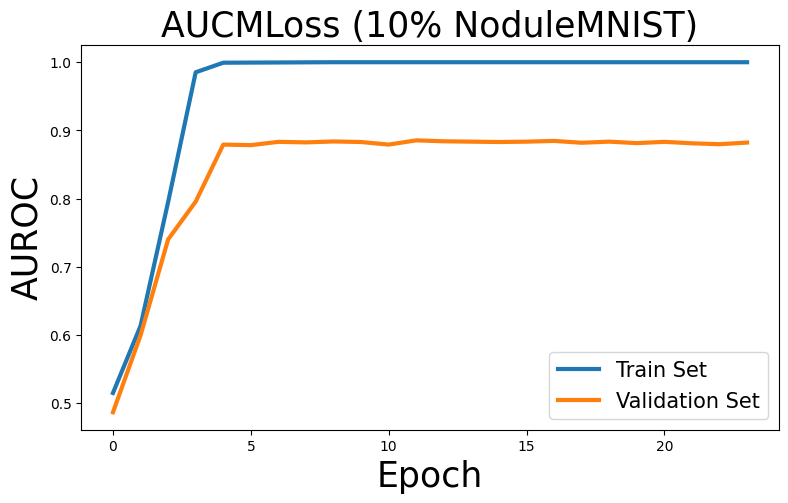

In [15]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (10% NoduleMNIST)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [16]:
X_test = torch.from_numpy(test_dataset.imgs.astype(np.float32) / 255.0)
test_d = torch.utils.data.TensorDataset(X_test, torch.from_numpy(test_dataset.labels))

test_loader = data.DataLoader(dataset=test_d, batch_size=BATCH_SIZE)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# eval mode: BatchNorm uses running statistics. Training leaves the model in train mode,
# where predictions would depend on batch composition
model_imblance.eval()
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model_imblance(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test : %.4f"%test_auc, flush=True)

Test : 0.8798


In [17]:
torch.save(model_imblance.state_dict(), "vessel/vessel_imbalance.pth")

## Baseline

Same ResNet-18 and data as `model_imblance`. Only the loss and optimizer change.

- `nn.BCEWithLogitsLoss` on the raw logit + Adam (lr 1e-3), no lr decay. Up to 50 epochs, patience 12.
- `train_with_logits_loss` validates after the first minibatch of each epoch, so the epoch in its restore message counts full epochs plus one step. The AUC-margin arms validate after each full epoch.
- The Baseline's validation ROC-AUC ranges from 0.569 to 0.949, so the selected checkpoint (0.949) is probably an optimistic pick.

In [18]:
# baseline data: same raw, unaugmented, natural-frequency volumes as model_imblance
X_train_bce = torch.from_numpy(train_dataset1.imgs.astype(np.float32) / 255.0)
y_train_bce = torch.from_numpy(train_dataset1.labels)

train_d_bce = torch.utils.data.TensorDataset(X_train_bce, y_train_bce)

val_imgs_bce = torch.from_numpy(val_dataset1.imgs.astype(np.float32) / 255.0)
val_labels_bce = torch.from_numpy(val_dataset1.labels)
val_d_bce = torch.utils.data.TensorDataset(val_imgs_bce, val_labels_bce)

BATCH_SIZE_BCE = 128  # same batch size as model_imblance

# plain shuffled loader, no class-balanced sampler
trainloader_bce = data.DataLoader(dataset=train_d_bce, batch_size=BATCH_SIZE_BCE, shuffle=True)
valloader_bce = data.DataLoader(dataset=val_d_bce, batch_size=BATCH_SIZE_BCE, shuffle=False, num_workers=2)
trainloader_eval_bce = data.DataLoader(train_d_bce, batch_size=BATCH_SIZE_BCE, shuffle=False, num_workers=2)

In [19]:
# same ResNet-18 as model_imblance, BCEWithLogitsLoss + Adam
model_baseline_bce = ResNet18(pretrained=False, last_activation=None, num_classes=1)
model_baseline_bce.conv1 = torch.nn.Conv2d(X_train_bce.shape[1], 64, kernel_size=7, stride=2, padding=3, bias=False)

total_epochs_bce = 50  # same budget as model_imblance
lr_bce = 1e-3  # Adam default

loss_fn_bce = nn.BCEWithLogitsLoss()
optimizer_bce = torch.optim.Adam(model_baseline_bce.parameters(), lr=lr_bce)

In [20]:
# passes the raw logit to the loss (BCEWithLogitsLoss applies the sigmoid), unlike train()
# returns None: prints Val_AUC and restores the best-validation weights in place
patience_bce = 12
train_with_logits_loss(model_baseline_bce, loss_fn_bce, optimizer_bce, total_epochs_bce,
                       trainloader_bce, trainloader_eval_bce, valloader_bce, patience=patience_bce)

Start Training
------------------------------
device: cuda
Epoch=0, BatchID=0, Val_AUC=0.7924
0
Epoch=1, BatchID=0, Val_AUC=0.7063
1
Epoch=2, BatchID=0, Val_AUC=0.8483
0
Epoch=3, BatchID=0, Val_AUC=0.8876
0
Epoch=4, BatchID=0, Val_AUC=0.8211
1
Epoch=5, BatchID=0, Val_AUC=0.8696
0
Epoch=6, BatchID=0, Val_AUC=0.8978
0
Epoch=7, BatchID=0, Val_AUC=0.8419
1
Epoch=8, BatchID=0, Val_AUC=0.8841
0
Epoch=9, BatchID=0, Val_AUC=0.8938
0
Epoch=10, BatchID=0, Val_AUC=0.9285
0
Epoch=11, BatchID=0, Val_AUC=0.8561
1
Epoch=12, BatchID=0, Val_AUC=0.9134
0
Epoch=13, BatchID=0, Val_AUC=0.9169
1
Epoch=14, BatchID=0, Val_AUC=0.7501
2
Epoch=15, BatchID=0, Val_AUC=0.9467
0
Epoch=16, BatchID=0, Val_AUC=0.8236
1
Epoch=17, BatchID=0, Val_AUC=0.5799
2
Epoch=18, BatchID=0, Val_AUC=0.5689
3
Epoch=19, BatchID=0, Val_AUC=0.9489
0
Epoch=20, BatchID=0, Val_AUC=0.8728
1
Epoch=21, BatchID=0, Val_AUC=0.9486
0
Epoch=22, BatchID=0, Val_AUC=0.8916
1
Epoch=23, BatchID=0, Val_AUC=0.9276
0
Epoch=24, BatchID=0, Val_AUC=0.9166
1
E

In [22]:
X_test_bce = torch.from_numpy(test_dataset.imgs.astype(np.float32) / 255.0)
test_d_bce = torch.utils.data.TensorDataset(X_test_bce, torch.from_numpy(test_dataset.labels))

test_loader_bce = data.DataLoader(dataset=test_d_bce, batch_size=BATCH_SIZE_BCE)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_baseline_bce.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader_bce, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model_baseline_bce(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label_bce = torch.cat(label_list)
test_score_bce = torch.cat(score_list)

test_auc_bce = metrics.roc_auc_score(test_label_bce, test_score_bce)
print("Test (model_baseline_bce, BCEWithLogitsLoss + Adam) : %.4f"%test_auc_bce, flush=True)

Test (model_baseline_bce, BCEWithLogitsLoss + Adam) : 0.9291


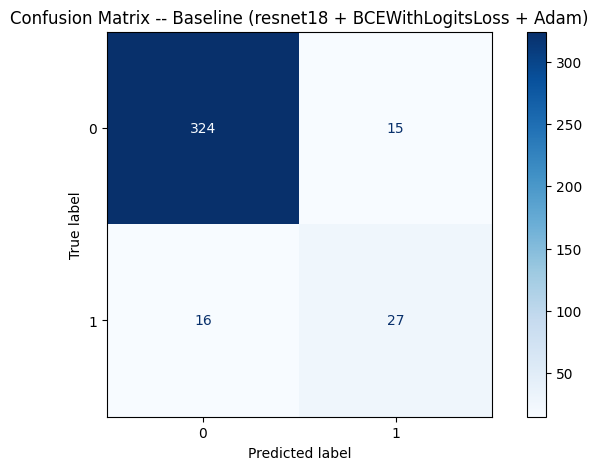

              precision    recall  f1-score   support

           0     0.9529    0.9558    0.9543       339
           1     0.6429    0.6279    0.6353        43

    accuracy                         0.9188       382
   macro avg     0.7979    0.7918    0.7948       382
weighted avg     0.9180    0.9188    0.9184       382

Balanced accuracy: 0.7918
PR-AUC (average precision): 0.7097
Matthews correlation coefficient: 0.5897


In [23]:
# confusion matrix and threshold metrics at 0.5 for the Baseline
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              balanced_accuracy_score, average_precision_score, matthews_corrcoef)

prob = torch.sigmoid(test_score_bce).numpy().reshape(-1)  # logit -> probability
y_true = test_label_bce.numpy().astype(int).reshape(-1)
y_pred = (prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title('Confusion Matrix -- Baseline (resnet18 + BCEWithLogitsLoss + Adam)')
plt.show()

print(classification_report(y_true, y_pred, digits=4))
print('Balanced accuracy: %.4f' % balanced_accuracy_score(y_true, y_pred))
# PR-AUC (average precision), positive class = label 1 = aneurysm (minority)
print('PR-AUC (average precision): %.4f' % average_precision_score(y_true, prob))
print('Matthews correlation coefficient: %.4f' % matthews_corrcoef(y_true, y_pred))

In [24]:
torch.save(model_baseline_bce.state_dict(), "vessel/vessel_baseline_bce.pth")

## Augmentation and sampling (Conv3d)

MONAI 3D transforms, applied on the fly to every training volume:

- flip along the depth axis (p = 0.5)
- rotation up to 0.26 rad about each axis (p = 0.5)
- 3D elastic deformation (sigma 3 to 5, displacement 2 to 6 voxels, p = 0.3)
- Gaussian noise (std 0.1, p = 0.3)

Batches come from `DualSampler` (`sampling_rate=0.5`, batch size 32), see Overview.

In [25]:
# MONAI 3D augmentations, each with its own probability, applied to every training volume regardless of class
import monai.transforms as mt

def flip_aug(img):
    return mt.RandFlip(prob=0.5, spatial_axis=0)(img)  # flips the depth axis

def rotate_aug(img):
    return mt.RandRotate(range_x=0.26, range_y=0.26, range_z=0.26, prob=0.5,
                          mode="bilinear", padding_mode="zeros")(img)

def elastic_aug(img):
    # magnitude_range is a displacement in voxels
    return mt.Rand3DElastic(sigma_range=(3, 5), magnitude_range=(2, 6), prob=0.3,
                             mode="bilinear", padding_mode="zeros")(img)

def noise_aug(img):
    return mt.RandGaussianNoise(prob=0.3, mean=0.0, std=0.1)(img)

## Hand-picked

Does a true 3D convolution help over the 2.5D ResNet-18?

- torchvision `r3d_18`, random init, first conv replaced to take 1 channel (kernel 3x7x7, stride 1x2x2), 1-logit linear head.
- `AUCMLoss_V2` + `PESG`, not tuned: lr 0.05, momentum 0.9, margin 1.0, epoch_decay 0.003, weight decay 5e-4.
- All four augmentations, `DualSampler`, batch size 32. Up to 50 epochs, lr divided by 10 at epochs 25 and 40, patience 12.

The Conv3d arms also differ from the 2.5D arms in loss, sampling and augmentation, so a gap can't be pinned on the 3D convolution alone.

In [27]:
from torchvision.models.video import r3d_18

# keeps the (1, D, H, W) channel axis that Conv3d needs
def make_augment_conv3d(funcs):
    def augment(img):
        if isinstance(img, np.ndarray):
            img = torch.from_numpy(img)
        img = img.float()
        for f in funcs:
            img = f(img)
        return img  # keep the channel dim
    return augment

BATCH_SIZE_3D = 32  # batch size for the Conv3d models

train_d_3d = OnTheFlyAugment(train_dataset1, make_augment_conv3d([flip_aug, noise_aug, rotate_aug, elastic_aug]))

# DualSampler: fixed class ratio per batch, see Overview
sampler_3d = DualSampler(train_d_3d, batch_size=BATCH_SIZE_3D, labels=train_dataset1.labels, sampling_rate=0.5)
trainloader_3d = data.DataLoader(dataset=train_d_3d, batch_size=BATCH_SIZE_3D, sampler=sampler_3d)
trainloader_eval_3d = data.DataLoader(train_d_3d, batch_size=BATCH_SIZE_3D, shuffle=False, num_workers=2)

val_imgs_3d = torch.from_numpy(val_dataset1.imgs.astype(np.float32) / 255.0).unsqueeze(1)  # (N, D, H, W) -> (N, 1, D, H, W)
val_labels_3d = torch.from_numpy(val_dataset1.labels)
val_d_3d = torch.utils.data.TensorDataset(val_imgs_3d, val_labels_3d)
valloader_3d = data.DataLoader(dataset=val_d_3d, batch_size=BATCH_SIZE_3D, shuffle=False, num_workers=2)

In [28]:
# r3d_18 from scratch with a 1-channel stem and a 1-logit head
model_conv3d = r3d_18(weights=None)
model_conv3d.stem[0] = torch.nn.Conv3d(1, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False)
model_conv3d.fc = torch.nn.Linear(model_conv3d.fc.in_features, 1)

# hand-picked hyperparameters (not tuned)
total_epochs = 50
decay_epochs = [25, 40]  # 50% / 80% of total_epochs

lr = 0.05
margin = 1.0
epoch_decay = 0.003
weight_decay = 0.0005

loss_fn = AUCMLoss_V2(margin=margin)  # needs DualSampler (both classes in every batch)
optimizer = PESG(model_conv3d,
                 loss_fn=loss_fn,
                 lr=lr,
                 momentum=0.9,
                 margin=margin,
                 epoch_decay=epoch_decay,
                 weight_decay=weight_decay)

In [29]:
patience = 12
train_log_3d, val_log_3d = train(model_conv3d, loss_fn, optimizer, total_epochs, trainloader_3d,
                                  trainloader_eval_3d, valloader_3d, patience=patience, decay_epochs=decay_epochs)

Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.9414, train_auc: 0.3178, val_auc: 0.2006, lr: 0.0500
0
epoch: 1, train_loss: 1.0003, train_auc: 0.3345, val_auc: 0.2012, lr: 0.0500
1
epoch: 2, train_loss: 1.0002, train_auc: 0.3356, val_auc: 0.2009, lr: 0.0500
2
epoch: 3, train_loss: 1.0002, train_auc: 0.3674, val_auc: 0.2001, lr: 0.0500
3
epoch: 4, train_loss: 1.0001, train_auc: 0.3402, val_auc: 0.2006, lr: 0.0500
4
epoch: 5, train_loss: 1.0001, train_auc: 0.3381, val_auc: 0.2012, lr: 0.0500
5
epoch: 6, train_loss: 1.0001, train_auc: 0.3674, val_auc: 0.1993, lr: 0.0500
6
epoch: 7, train_loss: 1.0001, train_auc: 0.3398, val_auc: 0.1985, lr: 0.0500
7
epoch: 8, train_loss: 1.0001, train_auc: 0.4140, val_auc: 0.1990, lr: 0.0500
8
epoch: 9, train_loss: 1.0001, train_auc: 0.3913, val_auc: 0.1998, lr: 0.0500
9
epoch: 10, train_loss: 1.0001, train_auc: 0.4090, val_auc: 0.2004, lr: 0.0500
10
epoch: 11, train_loss: 1.0000, train_auc: 0.5041, val_auc: 0.2052, lr:

Text(0.5, 0, 'Epoch')

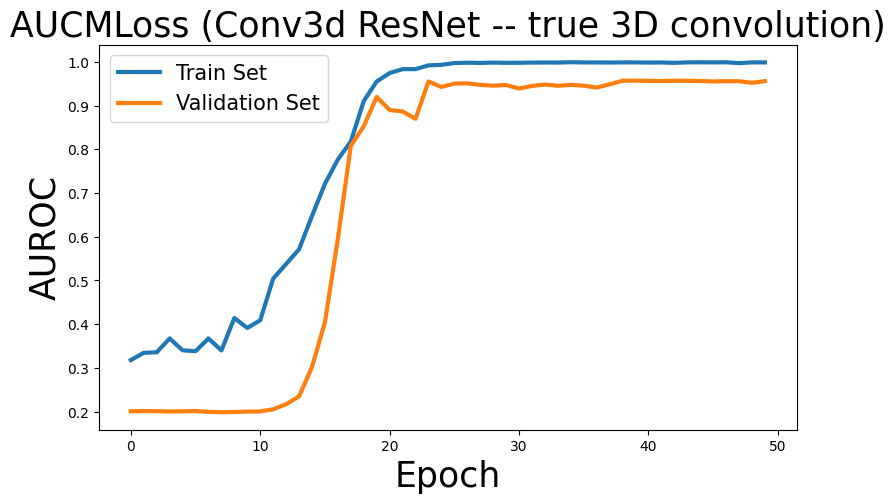

In [30]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log_3d))
plt.figure()
plt.plot(x, train_log_3d, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log_3d,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (Conv3d ResNet -- true 3D convolution)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [31]:
X_test_3d = torch.from_numpy(test_dataset.imgs.astype(np.float32) / 255.0).unsqueeze(1)  # (N, D, H, W) -> (N, 1, D, H, W)
test_d_3d = torch.utils.data.TensorDataset(X_test_3d, torch.from_numpy(test_dataset.labels))
test_loader_3d = data.DataLoader(dataset=test_d_3d, batch_size=BATCH_SIZE_3D)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_conv3d.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader_3d, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model_conv3d(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test (Conv3d ResNet) : %.4f"%test_auc, flush=True)

Test (Conv3d ResNet) : 0.9284


In [32]:
torch.save(model_conv3d.state_dict(), "vessel/vessel_model_conv3d.pth")

## Optuna tuning

Tunes the hand-picked Conv3d recipe. `sampling_rate` (0.5) and the augmentation stay fixed.

- Search space: batch size in {16, 32, 64}, lr log-uniform in [0.02, 0.15], weight decay log-uniform in [2e-4, 1.5e-3], margin uniform in [0.8, 1.3], epoch_decay log-uniform in [1e-3, 8e-3].
- TPE sampler, 30 trials (the first 10 random). Each trial trains up to 10 epochs with lr decay at epochs 5 and 8 and patience 4. The objective is the best validation ROC-AUC in the trial.
- The best parameters are retrained for up to 50 epochs (decay at 25 and 40, patience 12).
- The best lr, weight decay and margin are near the lower ends of their ranges, so the ranges may have cut off better values.

In [34]:
def build_model(trial):
    # fresh model every trial: same 1-channel stem and 1-logit head as model_conv3d
    model_trial = r3d_18(weights=None)
    model_trial.stem[0] = torch.nn.Conv3d(
        1, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False
    )
    model_trial.fc = torch.nn.Linear(model_trial.fc.in_features, 1)
    return model_trial


def build_loaders(trial):
    # batch size is searched over {16, BATCH_SIZE_3D (32), 64}
    batch_size_trial = trial.suggest_categorical("batch_size", [16, BATCH_SIZE_3D, 64])

    # fresh dataset wrapper, sampler and loaders per trial (the sampler depends on the batch size)
    # sampling_rate fixed at 0.5, as in model_conv3d
    train_d_3d_trial = OnTheFlyAugment(
        train_dataset1, make_augment_conv3d([flip_aug, noise_aug, rotate_aug, elastic_aug])
    )
    sampler_3d_trial = DualSampler(
        train_d_3d_trial, batch_size=batch_size_trial,
        labels=train_dataset1.labels, sampling_rate=0.5,
    )
    trainloader_3d_trial = data.DataLoader(
        dataset=train_d_3d_trial, batch_size=batch_size_trial, sampler=sampler_3d_trial
    )
    trainloader_eval_3d_trial = data.DataLoader(
        train_d_3d_trial, batch_size=batch_size_trial, shuffle=False, num_workers=2
    )
    # val_d_3d does not depend on the batch size; only its loader does
    valloader_3d_trial = data.DataLoader(
        dataset=val_d_3d, batch_size=batch_size_trial, shuffle=False, num_workers=2
    )
    return trainloader_3d_trial, trainloader_eval_3d_trial, valloader_3d_trial


def build_loss_optimizer(trial, model):
    # lr and weight_decay: log-uniform within about 3x of the hand-picked values (lr 0.05, weight_decay 5e-4)
    lr_trial = trial.suggest_float("lr", 2e-2, 1.5e-1, log=True)
    weight_decay_trial = trial.suggest_float("weight_decay", 2e-4, 1.5e-3, log=True)
    # margin and epoch_decay: searched around the hand-picked values (margin 1.0, epoch_decay 0.003)
    margin_trial = trial.suggest_float("margin", 0.8, 1.3)
    epoch_decay_trial = trial.suggest_float("epoch_decay", 1e-3, 8e-3, log=True)

    loss_fn_trial = AUCMLoss_V2(margin=margin_trial)  # needs DualSampler (both classes in every batch)
    optimizer_trial = PESG(
        model,
        loss_fn=loss_fn_trial,
        lr=lr_trial,
        momentum=0.9,
        margin=margin_trial,
        epoch_decay=epoch_decay_trial,
        weight_decay=weight_decay_trial,
    )
    return loss_fn_trial, optimizer_trial


def score_fn(model, valloader, train_fn_result):
    # best validation ROC-AUC in the trial (train_fn_result[1] is val_log, the per-epoch val ROC-AUC)
    return max(train_fn_result[1])

In [35]:
# search budget per trial: 10 epochs, lr decay at 5 and 8 (50% / 80%), patience 4
total_epochs_search = 10
decay_epochs_search = [5, 8]
patience_search = 4

# 30 trials: first 10 random startup (n_startup_trials=10), the rest TPE-guided
# catch=(ValueError,): a trial that diverges to NaN makes roc_auc_score raise, it's recorded as failed and the study continues
from hyperparameter_tuning import run_optuna_search, retrain_with_best_params

study = run_optuna_search(build_model, build_loaders, build_loss_optimizer, train, score_fn,
                           n_trials=30, search_epochs=total_epochs_search,
                           search_decay_epochs=decay_epochs_search,
                           search_patience=patience_search,
                           catch=(ValueError,))
print(study.best_params)
print(study.best_value)

[I 2026-09-24 12:47:08,584] A new study created in memory with name: no-name-c6136067-f273-42f0-a047-2bf964877833


Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 1.2977, train_auc: 0.3235, val_auc: 0.2297, lr: 0.1220
0
epoch: 1, train_loss: 1.3351, train_auc: 0.3387, val_auc: 0.2270, lr: 0.1220
1
epoch: 2, train_loss: 1.3351, train_auc: 0.3184, val_auc: 0.2265, lr: 0.1220
2
epoch: 3, train_loss: 1.3351, train_auc: 0.3104, val_auc: 0.2265, lr: 0.1220
3


[I 2026-09-24 12:49:23,901] Trial 0 finished with value: 0.2296933835395374 and parameters: {'batch_size': 32, 'lr': 0.1219620108390295, 'weight_decay': 0.0010230603480758708, 'margin': 1.155461207287099, 'epoch_decay': 0.002112382508271424}. Best is trial 0 with value: 0.2296933835395374.


epoch: 4, train_loss: 1.3351, train_auc: 0.3268, val_auc: 0.2254, lr: 0.1220
4
Early stopping
Restoring best checkpoint: epoch 0, val_auc 0.2297
Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.6209, train_auc: 0.7190, val_auc: 0.7031, lr: 0.0205
0
epoch: 1, train_loss: 0.4763, train_auc: 0.8914, val_auc: 0.8222, lr: 0.0205
0
epoch: 2, train_loss: 0.1827, train_auc: 0.9582, val_auc: 0.7786, lr: 0.0205
1
epoch: 3, train_loss: 0.1003, train_auc: 0.9842, val_auc: 0.8523, lr: 0.0205
0
epoch: 4, train_loss: 0.0727, train_auc: 0.9887, val_auc: 0.8488, lr: 0.0205
1
Reducing learning rate to 0.00205 @ T=370!
Updating regularizer @ T=370!
epoch: 5, train_loss: 0.0392, train_auc: 0.9957, val_auc: 0.8429, lr: 0.0021
2
epoch: 6, train_loss: 0.0284, train_auc: 0.9948, val_auc: 0.8618, lr: 0.0021
0
epoch: 7, train_loss: 0.0233, train_auc: 0.9990, val_auc: 0.8440, lr: 0.0021
1
Reducing learning rate to 0.00021 @ T=592!
Updating regularizer @ T=592!
epoch: 8, train_lo

[I 2026-09-24 12:53:53,859] Trial 1 finished with value: 0.8617536309844002 and parameters: {'batch_size': 32, 'lr': 0.020512253353767218, 'weight_decay': 0.0003912103774628203, 'margin': 0.8559324082543761, 'epoch_decay': 0.0015980170364380847}. Best is trial 1 with value: 0.8617536309844002.


...

epoch: 9, train_loss: 0.0202, train_auc: 0.9985, val_auc: 0.8868, lr: 0.0002
2
Restoring best checkpoint: epoch 2, val_auc 0.8924
Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.8300, train_auc: 0.5550, val_auc: 0.2741, lr: 0.0337
0
epoch: 1, train_loss: 0.8873, train_auc: 0.7515, val_auc: 0.8133, lr: 0.0337
0
epoch: 2, train_loss: 0.4623, train_auc: 0.8832, val_auc: 0.8186, lr: 0.0337
0
epoch: 3, train_loss: 0.2372, train_auc: 0.9613, val_auc: 0.8263, lr: 0.0337
0
epoch: 4, train_loss: 0.1656, train_auc: 0.9790, val_auc: 0.8623, lr: 0.0337
0
Reducing learning rate to 0.00337 @ T=370!
Updating regularizer @ T=370!
epoch: 5, train_loss: 0.0615, train_auc: 0.9898, val_auc: 0.8943, lr: 0.0034
0
epoch: 6, train_loss: 0.0474, train_auc: 0.9959, val_auc: 0.9056, lr: 0.0034
0
epoch: 7, train_loss: 0.0415, train_auc: 0.9943, val_auc: 0.9115, lr: 0.0034
0
Reducing learning rate to 0.00034 @ T=592!
Updating regularizer @ T=592!
epoch: 8, train_loss: 0.0323, tra

[I 2026-09-24 14:51:05,968] Trial 28 finished with value: 0.9139322216245294 and parameters: {'batch_size': 32, 'lr': 0.03369521278653985, 'weight_decay': 0.00042344344200460064, 'margin': 0.9580592039773611, 'epoch_decay': 0.002096375870246789}. Best is trial 23 with value: 0.9179666487358794.


epoch: 9, train_loss: 0.0345, train_auc: 0.9951, val_auc: 0.9139, lr: 0.0003
2
Restoring best checkpoint: epoch 8, val_auc 0.9139
Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.6549, train_auc: 0.3884, val_auc: 0.2310, lr: 0.0284
0
epoch: 1, train_loss: 0.7298, train_auc: 0.5807, val_auc: 0.2617, lr: 0.0284
0
epoch: 2, train_loss: 0.7283, train_auc: 0.7506, val_auc: 0.6993, lr: 0.0284
0
epoch: 3, train_loss: 0.5191, train_auc: 0.8798, val_auc: 0.8066, lr: 0.0284
0
epoch: 4, train_loss: 0.2190, train_auc: 0.9569, val_auc: 0.8209, lr: 0.0284
0
Reducing learning rate to 0.00284 @ T=370!
Updating regularizer @ T=370!
epoch: 5, train_loss: 0.0745, train_auc: 0.9822, val_auc: 0.8534, lr: 0.0028
0
epoch: 6, train_loss: 0.0410, train_auc: 0.9881, val_auc: 0.8448, lr: 0.0028
1
epoch: 7, train_loss: 0.0291, train_auc: 0.9947, val_auc: 0.8612, lr: 0.0028
0
Reducing learning rate to 0.00028 @ T=592!
Updating regularizer @ T=592!
epoch: 8, train_loss: 0.0227, tra

[I 2026-09-24 14:55:41,510] Trial 29 finished with value: 0.863905325443787 and parameters: {'batch_size': 32, 'lr': 0.02840983372709128, 'weight_decay': 0.0003338434412026152, 'margin': 0.8541545490184765, 'epoch_decay': 0.0016105895477702859}. Best is trial 23 with value: 0.9179666487358794.


epoch: 9, train_loss: 0.0183, train_auc: 0.9947, val_auc: 0.8639, lr: 0.0003
2
Restoring best checkpoint: epoch 9, val_auc 0.8639
{'batch_size': 32, 'lr': 0.026185183851954046, 'weight_decay': 0.00023219734388827605, 'margin': 0.8391182981098918, 'epoch_decay': 0.002110545374111062}
0.9179666487358794


In [36]:
print("Best hyperparameters (model_conv3d, Optuna search):", study.best_params)
print("Best validation AUC (reduced search budget): %.4f" % study.best_value)

Best hyperparameters (model_conv3d, Optuna search): {'batch_size': 32, 'lr': 0.026185183851954046, 'weight_decay': 0.00023219734388827605, 'margin': 0.8391182981098918, 'epoch_decay': 0.002110545374111062}
Best validation AUC (reduced search budget): 0.9180


### Optuna-tuned Conv3d

In [37]:
# retrain the best params at the full budget (50 epochs, decay at [25, 40], patience 12)
# retrain_with_best_params rebuilds everything with the same build_* functions via optuna.trial.FixedTrial(study.best_params)
model_conv3d_tuned, loss_fn_tuned, optimizer_tuned, (train_log_3d_tuned, val_log_3d_tuned) = retrain_with_best_params(
    study, build_model, build_loaders, build_loss_optimizer, train,
    full_epochs=50, full_decay_epochs=[25, 40], full_patience=12)

# batch size for the test loader below
best_batch_size = study.best_params["batch_size"]

Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.6206, train_auc: 0.5669, val_auc: 0.3349, lr: 0.0262
0
epoch: 1, train_loss: 0.6659, train_auc: 0.7894, val_auc: 0.7918, lr: 0.0262
0
epoch: 2, train_loss: 0.2888, train_auc: 0.9261, val_auc: 0.8478, lr: 0.0262
0
epoch: 3, train_loss: 0.1345, train_auc: 0.9754, val_auc: 0.8749, lr: 0.0262
0
epoch: 4, train_loss: 0.0731, train_auc: 0.9824, val_auc: 0.8930, lr: 0.0262
0
epoch: 5, train_loss: 0.0594, train_auc: 0.9942, val_auc: 0.9185, lr: 0.0262
0
epoch: 6, train_loss: 0.0428, train_auc: 0.9973, val_auc: 0.8650, lr: 0.0262
1
epoch: 7, train_loss: 0.0353, train_auc: 0.9939, val_auc: 0.9024, lr: 0.0262
0
epoch: 8, train_loss: 0.0292, train_auc: 0.9982, val_auc: 0.8615, lr: 0.0262
1
epoch: 9, train_loss: 0.0272, train_auc: 0.9923, val_auc: 0.9016, lr: 0.0262
0
epoch: 10, train_loss: 0.0243, train_auc: 0.9996, val_auc: 0.8932, lr: 0.0262
1
epoch: 11, train_loss: 0.0228, train_auc: 0.9982, val_auc: 0.9077, lr: 

In [ ]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log_3d_tuned))
plt.figure()
plt.plot(x, train_log_3d_tuned, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log_3d_tuned,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (Conv3d ResNet -- Optuna-tuned)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [ ]:
X_test_3d_tuned = torch.from_numpy(test_dataset.imgs.astype(np.float32) / 255.0).unsqueeze(1)  # (N, D, H, W) -> (N, 1, D, H, W)
test_d_3d_tuned = torch.utils.data.TensorDataset(X_test_3d_tuned, torch.from_numpy(test_dataset.labels))
test_loader_3d_tuned = data.DataLoader(dataset=test_d_3d_tuned, batch_size=best_batch_size)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_conv3d_tuned.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader_3d_tuned, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model_conv3d_tuned(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test (Conv3d ResNet, Optuna-tuned) : %.4f"%test_auc, flush=True)

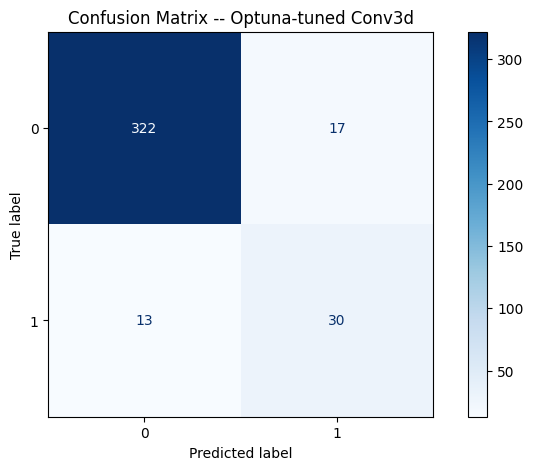

              precision    recall  f1-score   support

           0     0.9612    0.9499    0.9555       339
           1     0.6383    0.6977    0.6667        43

    accuracy                         0.9215       382
   macro avg     0.7997    0.8238    0.8111       382
weighted avg     0.9248    0.9215    0.9230       382

Balanced accuracy: 0.8238
PR-AUC (average precision): 0.7563
Matthews correlation coefficient: 0.6230


In [40]:
# confusion matrix and threshold metrics at 0.5 for the Optuna-tuned Conv3d
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              balanced_accuracy_score, average_precision_score, matthews_corrcoef)

prob = torch.sigmoid(test_score).numpy().reshape(-1)  # logit -> probability
y_true = test_label.numpy().astype(int).reshape(-1)
y_pred = (prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title('Confusion Matrix -- Optuna-tuned Conv3d')
plt.show()

print(classification_report(y_true, y_pred, digits=4))
print('Balanced accuracy: %.4f' % balanced_accuracy_score(y_true, y_pred))
# PR-AUC (average precision), positive class = label 1 = aneurysm (minority)
print('PR-AUC (average precision): %.4f' % average_precision_score(y_true, prob))
print('Matthews correlation coefficient: %.4f' % matthews_corrcoef(y_true, y_pred))

In [41]:
torch.save(model_conv3d_tuned.state_dict(), "vessel/vessel_model_conv3d_tuned.pth")

## Results

Test set: 382 volumes, 43 aneurysm (label 1). Val AUC is the restored checkpoint's, with its 0-based epoch in parentheses. "-" means not computed.

| Arm | Val AUC (epoch) | Test ROC-AUC | Bal. acc. @0.5 | MCC @0.5 | PR-AUC (aneurysm) | Aneurysm recall / F1 @0.5 |
|---|---|---|---|---|---|---|
| AUCM, no balancing (`model_imblance`) | 0.8854 (11) | 0.8798 | - | - | - | - |
| Baseline (ResNet-18 + BCEWithLogitsLoss + Adam, no augmentation, no balancing) | 0.9489 (19) | 0.9291 | 0.7918 | 0.5897 | 0.7097 | 0.6279 / 0.6353 |
| Hand-picked (Conv3d, LibAUC recipe, fixed hyperparameters) | 0.9572 (39) | 0.9284 | - | - | - | - |
| Optuna-tuned (Conv3d, hand-picked recipe after search) | 0.9242 (14) | not recorded | 0.8238 | 0.6230 | 0.7563 | 0.6977 / 0.6667 |

Only Baseline and Optuna-tuned have every metric (the tuned model's test ROC-AUC isn't recorded), so the metric comparison below uses just those two.

Optuna best: batch size 32, lr 0.0262, weight decay 2.3e-4, margin 0.839, epoch_decay 2.1e-3 (search value 0.918 at the 10-epoch budget).

### Takeaways

- The tuned Conv3d is higher than the Baseline on PR-AUC, balanced accuracy, MCC and aneurysm recall/F1, with about equal precision (0.638 vs. 0.643). Its test ROC-AUC isn't recorded, so that comparison is missing.
- On test ROC-AUC the Baseline (0.929) ties the hand-picked Conv3d (0.928), so the AUC-margin recipe shows no gain here. The arms also differ in architecture, sampler and augmentation. AUCM without balancing is lower (0.880). Its training ROC-AUC is 1.0 by epoch 8 and validation is flat from epoch 4.
- Balanced accuracy, MCC and recall/F1 are at 0.5. `DualSampler` shifts the Conv3d arms' scores relative to 0.5, so ROC-AUC and PR-AUC are the cleaner comparison.
- 7 of 30 Optuna trials scored below 0.5 validation ROC-AUC, all with lr of at least 0.033. The hand-picked Conv3d (lr 0.05) also stayed below 0.5 for epochs 0 to 15.

The test set is small (382 volumes, 43 aneurysm) with only 22 aneurysms in validation, so small gaps may be noise.